# Atividade 001 — Pipeline de Classificação
**Disciplina:** Inteligência Artificial  
**Dataset Escolhido:** Penguins (Seaborn)

### Parte 1 — Definição do problema
*   **Dataset:** `penguins`
*   **Target (y):** `species` (Adelie, Chinstrap ou Gentoo)
*   **Problema:** Classificação Multiclasse
*   **Features (X):** `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`, `island`, `sex`.
*   **Remoções:** Nenhuma coluna será removida inicialmente, mas trataremos valores nulos.

In [10]:
import seaborn as sns
import pandas as pd

# Carregando o dataset
df = sns.load_dataset('penguins')

# Parte 2 — Diagnóstico dos dados
print(f"Tamanho do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas\n")
print("--- Tipos de Colunas ---")
print(df.dtypes)
print("\n--- Valores Ausentes (Missing) ---")
print(df.isnull().sum())
print("\n--- Distribuição do Target (Espécies) ---")
print(df['species'].value_counts())

display(df.head())

Tamanho do dataset: 344 linhas e 7 colunas

--- Tipos de Colunas ---
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

--- Valores Ausentes (Missing) ---
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

--- Distribuição do Target (Espécies) ---
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### Parte 3 — Construção do Pipeline
Nesta etapa, vamos automatizar o tratamento dos dados:
1. **Numéricas:** Imputação (mediana) + Padronização.
2. **Categóricas:** Imputação (mais frequente) + One-Hot Encoding.
3. **Divisão:** 80% para treino e 20% para teste.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Separando X (features) e y (target)
X = df.drop('species', axis=1)
y = df['species']

# 2. Identificando colunas
num_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
cat_features = ['island', 'sex']

# 3. Criando os 'scripts' de automação (Transformers)
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Preenche nulos com a mediana
    ('scaler', StandardScaler())                  # Coloca na mesma escala
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Preenche nulos com o mais comum
    ('onehot', OneHotEncoder(handle_unknown='ignore'))   # Transforma texto em colunas 0/1
])

# 4. Consolidando o Preprocessador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ])

# 5. Divisão Treino/Teste (Train/Test Split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Pipeline de pré-processamento configurado e dados divididos!")
print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")

Pipeline de pré-processamento configurado e dados divididos!
Treino: 275 amostras
Teste: 69 amostras


### Parte 4 — Modelos (Baseline + Melhoria)

*   **Baseline:** `LogisticRegression` — Simples e linear, serve como ponto de partida.
*   **Melhoria:** `RandomForestClassifier` — Modelo de conjunto (ensemble) que costuma capturar melhor relações não lineares.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Criando o Pipeline completo para o Baseline
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

# 2. Criando o Pipeline completo para a Melhoria
improved_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# 3. Treinando os modelos
baseline_model.fit(X_train, y_train)
improved_model.fit(X_train, y_train)

print("Modelos treinados com sucesso!")

Modelos treinados com sucesso!


### Parte 5 — Avaliação
Vamos comparar o desempenho dos dois modelos no conjunto de teste.

--- Avaliação: Baseline (Logistic Regression) ---
Acurácia: 0.9855

Relatório de Classificação:
              precision    recall  f1-score   support

      Adelie       0.97      1.00      0.98        32
   Chinstrap       1.00      0.94      0.97        16
      Gentoo       1.00      1.00      1.00        21

    accuracy                           0.99        69
   macro avg       0.99      0.98      0.98        69
weighted avg       0.99      0.99      0.99        69



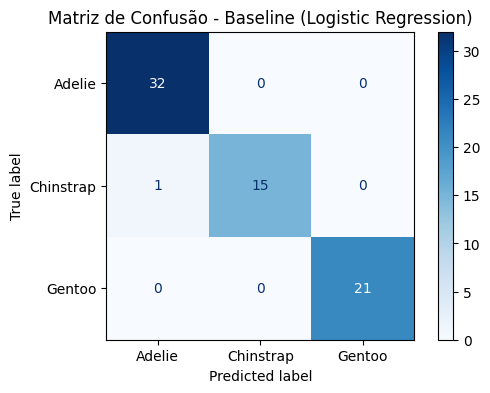



--- Avaliação: Melhoria (Random Forest) ---
Acurácia: 0.9855

Relatório de Classificação:
              precision    recall  f1-score   support

      Adelie       0.97      1.00      0.98        32
   Chinstrap       1.00      0.94      0.97        16
      Gentoo       1.00      1.00      1.00        21

    accuracy                           0.99        69
   macro avg       0.99      0.98      0.98        69
weighted avg       0.99      0.99      0.99        69



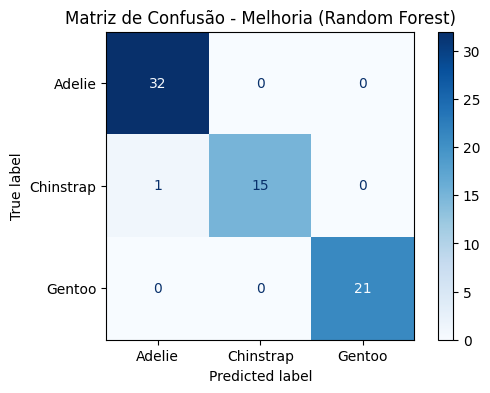

In [13]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def avaliar_modelo(modelo, nome):
    y_pred = modelo.predict(X_test)
    print(f"--- Avaliação: {nome} ---")
    print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")
    print("\nRelatório de Classificação:")
    print(classification_report(y_test, y_pred))

    # Plotando a Matriz de Confusão
    fig, ax = plt.subplots(figsize=(6, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues')
    ax.set_title(f'Matriz de Confusão - {nome}')
    plt.show()
    print("\n" + "="*40 + "\n")

# Executando a avaliação para ambos
avaliar_modelo(baseline_model, "Baseline (Logistic Regression)")
avaliar_modelo(improved_model, "Melhoria (Random Forest)")

### Parte 6 — Interpretação humana dos erros

**1. O que significa um FP (Falso Positivo) e FN (Falso Negativo) aqui?**
Como o problema é multiclasse, tratamos os erros como 'confusões' entre espécies:
*   **Exemplo de Erro:** O modelo previu `Adelie`, mas o pinguim era `Chinstrap`.
*   Neste contexto, um **Falso Positivo** para `Adelie` seria dizer que um pinguim de outra espécie é Adelie.
*   Um **Falso Negativo** para `Chinstrap` seria não reconhecer um Chinstrap real, classificando-o como outra coisa.

**2. Qual erro é mais grave?**
Neste cenário de estudo biológico, os erros não são críticos como em um diagnóstico médico. Porém, se o objetivo fosse preservação ambiental de uma espécie específica em extinção (ex: Chinstrap), o **Falso Negativo** seria mais grave, pois deixaríamos de proteger um indivíduo real.

**3. Análise dos Modelos:**
*   Ambos os modelos tiveram o mesmo desempenho (apenas 1 erro).
*   O erro ocorreu na classe `Chinstrap` (Recall de 0.94), que é justamente a classe com menos amostras no dataset. Isso sugere que o modelo tem um pouco mais de dificuldade com a espécie menos representada.

**4. Limitações e Melhorias (Bônus):**
*   **Limitação:** O dataset é pequeno (344 linhas). Com poucos dados, o modelo pode não generalizar bem para pinguins de outras regiões.
*   **Melhoria Sugerida:** Poderíamos realizar um `Tuning de Hiperparâmetros` no Random Forest ou usar `Cross-Validation` para garantir que a acurácia de 98% não foi apenas sorte na divisão dos dados.